In [40]:
#install scikit learn library
%pip install -U scikit-learn

In [41]:
pip install imbalanced-learn

In [3]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#install open cv library for image
%pip install opencv-python

# Import packages

In [87]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB


# Mount Google Drive to access uploaded files

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Get Train and Test images Features and labels

In [91]:
data1 = []
labels1 = []
root_folder = '/content/drive/MyDrive/Colab Notebooks/Alzheimer Dataset/train'  # Modify this path based on your dataset location
for label, folder_name in enumerate(os.listdir(root_folder)):
    folder_path = os.path.join(root_folder, folder_name)
    for file_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (50, 50))  # Resize the image to a consistent size
        data1.append(img.flatten())
        labels1.append(label)

X_train = np.array(data1)
y_train = np.array(labels1)

# Split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

data = []
labels = []
root_folder = '/content/drive/MyDrive/Colab Notebooks/Alzheimer Dataset/test'  # Modify this path based on your dataset location
for label, folder_name in enumerate(os.listdir(root_folder)):
    folder_path = os.path.join(root_folder, folder_name)
    for file_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (50, 50))  # Resize the image to a consistent size
        data.append(img.flatten())
        labels.append(label)

X_test = np.array(data)
y_test = np.array(labels)

# Check some values

In [26]:
print('features or pixels:'+str(data[1].size))
print('Training Data qty:'+str(y_train.size))
print('Testing Data qty:'+str(y_test.size))



features or pixels:2500
Training Data qty:5122
Testing Data qty:1279


# Check training data balance

In [49]:
class_distribution = pd.Series(y_train).value_counts(normalize=True)

print("Class distribution:")
print(class_distribution)


Class distribution:
3    0.499805
2    0.349863
1    0.139984
0    0.010348
dtype: float64


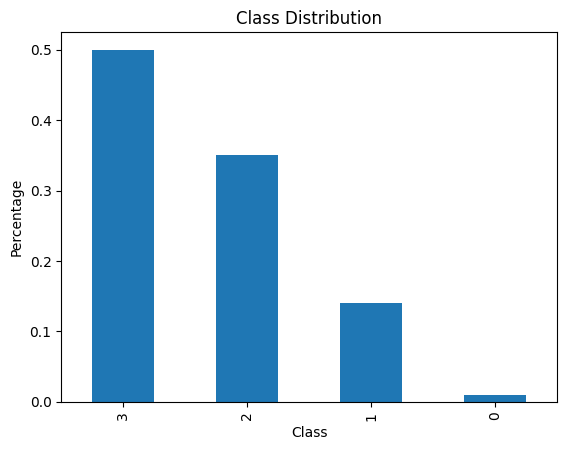

In [50]:
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.show()

# Apply under sampling and oversampling to correct data balance

In [65]:
# Assuming X_train and y_train are your training features and target
X_train_resampled1, y_train_resampled1 = resample(X_train, y_train,
                                                replace=True,    # Sample with replacement
                                                n_samples=len(X_train[y_train==0]), # Match number in minority class
                                                random_state=42) # Reproducible results

In [68]:
class_distribution = pd.Series(y_train_resampled1).value_counts(normalize=True)

print("Class distribution:")
print(class_distribution)

Class distribution:
3    0.433962
2    0.396226
1    0.150943
0    0.018868
dtype: float64


In [70]:
X_train_resampled, y_train_resampled = resample(X_train_resampled1, y_train_resampled1,
                                                replace=True,   # No replacement
                                                n_samples=len(X_train[y_train==3]), # Match number in majority class
                                                random_state=42) # Reproducible results

In [71]:
class_distribution = pd.Series(y_train_resampled).value_counts(normalize=True)

print("Class distribution:")
print(class_distribution)


Class distribution:
3    0.433984
2    0.401953
1    0.143359
0    0.020703
dtype: float64


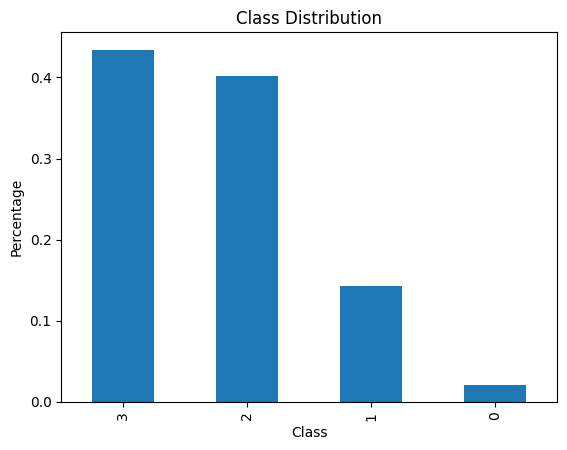

In [72]:
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.show()

# Apply PCA

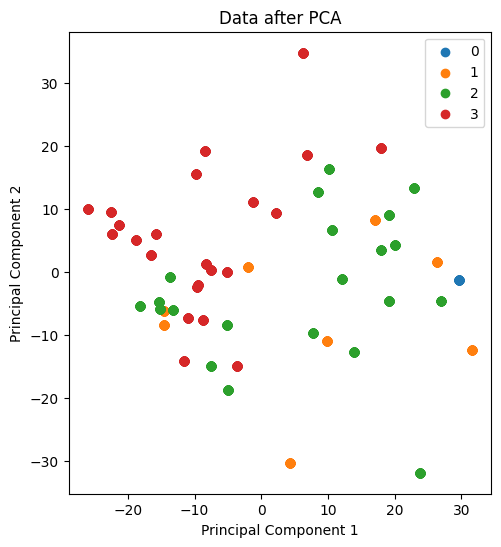

In [79]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
pca = PCA(n_components=2)  # Assuming you want to reduce to 2 components
X_train_pca = pca.fit_transform(X_train_scaled)  # Apply PCA to reduce dimensionality
# Plot the original data
plt.figure(figsize=(12, 6))

# Plot the data after PCA
plt.subplot(1, 2, 2)
for label in np.unique(y_train_resampled):
    plt.scatter(X_train_pca[y_train_resampled == label, 0], X_train_pca[y_train_resampled == label, 1], label=label)
plt.title('Data after PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()


plt.show()



# testing Data distribution

In [93]:
class_distribution = pd.Series(y_test).value_counts(normalize=True)

print("Class distribution:")
print(class_distribution)


Class distribution:
2    0.500391
1    0.350274
3    0.139953
0    0.009382
dtype: float64


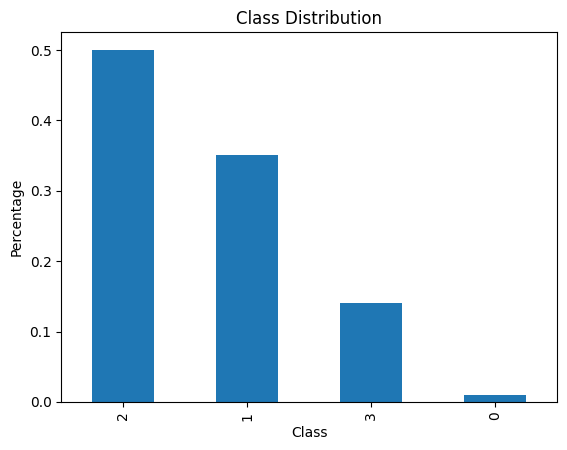

In [94]:
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.show()

# KNN with original data

In [92]:
# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Evaluate the model
accuracy = knn.score(X_test, y_test)
print(f"Accuracy: {accuracy}")


Accuracy: 0.11727912431587177


# KNN with resampled Data

In [84]:
# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled, y_train_resampled)

# Evaluate the model
accuracy = knn.score(X_test, y_test)
print(f"Accuracy: {accuracy}")


Accuracy: 0.12509773260359655


# random forest

In [86]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_resampled, y_train_resampled)
y_pred = rf_classifier.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)

Accuracy: 0.16262705238467554

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.88      0.02      0.03       448
           2       0.33      0.20      0.25       640
           3       0.08      0.40      0.13       179

    accuracy                           0.16      1279
   macro avg       0.32      0.15      0.10      1279
weighted avg       0.48      0.16      0.16      1279



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Naive bayesian

In [88]:
nb_classifier = GaussianNB()
nb_classifier.fit(X_train_resampled, y_train_resampled)
y_pred = nb_classifier.predict(X_test)
y_pred = nb_classifier.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)


Accuracy: 0.38076622361219703

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.00      0.00      0.00       448
           2       0.44      0.76      0.55       640
           3       0.01      0.01      0.01       179

    accuracy                           0.38      1279
   macro avg       0.11      0.19      0.14      1279
weighted avg       0.22      0.38      0.28      1279



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
